In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [16]:
np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "fever": np.random.randint(0, 2, n),
    "cough": np.random.randint(0, 2, n),
    "fatigue": np.random.randint(0, 2, n),
    "headache": np.random.randint(0, 2, n),
    "body_pain": np.random.randint(0, 2, n),
    "sore_throat": np.random.randint(0, 2, n),
    "breathing_problem": np.random.randint(0, 2, n)
})

score = (
    data["fever"]
    + data["cough"]
    + data["fatigue"]
    + data["headache"]
    + data["body_pain"]
    + data["sore_throat"]
    + data["breathing_problem"]
)

data["disease"] = (score >= 4).astype(int)

print("Dataset created successfully!")
print("Shape:", data.shape)

data.head()

Dataset created successfully!
Shape: (2000, 8)


,fever,cough,fatigue,headache,body_pain,sore_throat,breathing_problem,disease
0,0,0,1,0,1,0,0,0
1,1,1,0,0,0,1,0,0
2,0,1,0,0,1,0,0,0
3,0,1,0,1,0,1,0,0
4,0,1,1,0,0,1,0,0


In [17]:
print("Dataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDisease Distribution:")
print(data["disease"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   fever              2000 non-null   int64
 1   cough              2000 non-null   int64
 2   fatigue            2000 non-null   int64
 3   headache           2000 non-null   int64
 4   body_pain          2000 non-null   int64
 5   sore_throat        2000 non-null   int64
 6   breathing_problem  2000 non-null   int64
 7   disease            2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB
None

Missing Values:
fever                0
cough                0
fatigue              0
headache             0
body_pain            0
sore_throat          0
breathing_problem    0
disease              0
dtype: int64

Disease Distribution:
disease
1    1003
0     997
Name: count, dtype: int64


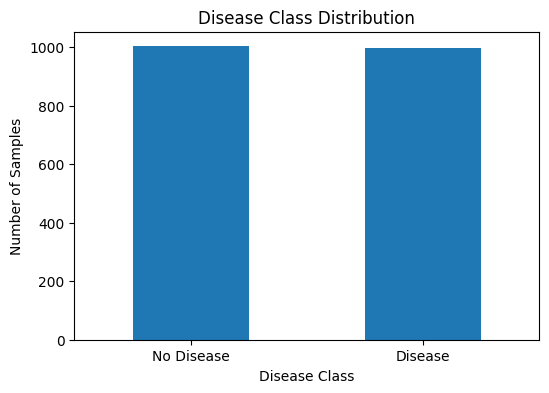

In [18]:
plt.figure(figsize=(6, 4))

data["disease"].value_counts().plot(kind="bar")

plt.title("Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Samples")
plt.xticks(
    [0, 1],
    ["No Disease", "Disease"],
    rotation=0
)

plt.show()

In [19]:
X = data.drop("disease", axis=1)
y = data["disease"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("disease")

Features:
['fever', 'cough', 'fatigue', 'headache', 'body_pain', 'sore_throat', 'breathing_problem']

Target:
disease


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed!
Training data shape: (1600, 7)
Testing data shape: (400, 7)


In [22]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [23]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


In [24]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Disease", "Disease"]
    )
)

Classification Report:

              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       199
     Disease       1.00      1.00      1.00       201

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



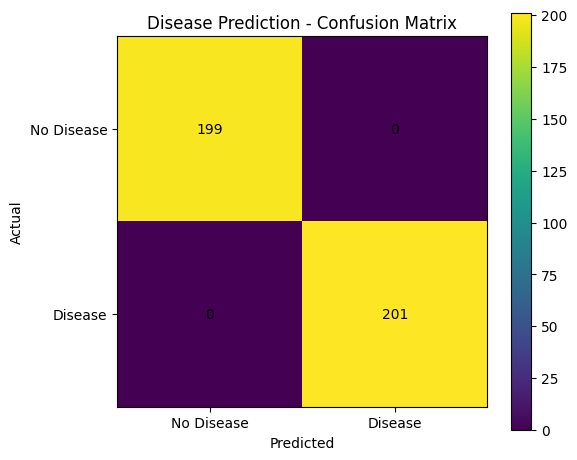

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.colorbar()

plt.title("Disease Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.yticks(
    [0, 1],
    ["No Disease", "Disease"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

             Feature  Importance
2            fatigue    0.166757
1              cough    0.147683
5        sore_throat    0.144855
6  breathing_problem    0.139775
4          body_pain    0.138249
0              fever    0.134598
3           headache    0.128084


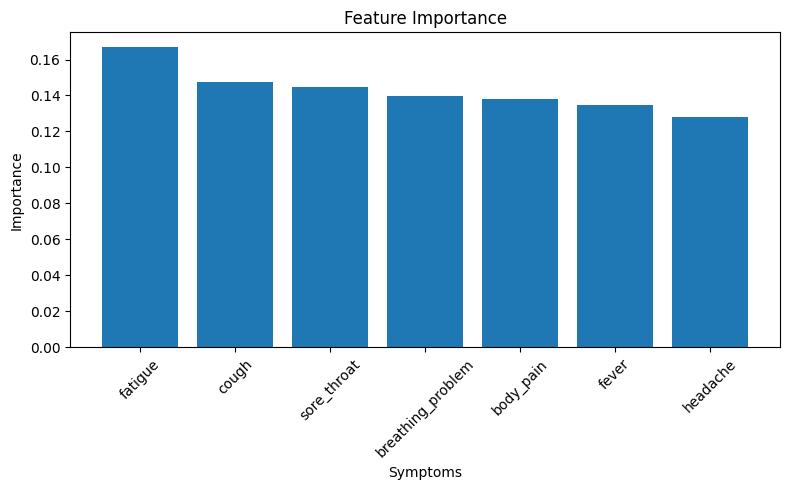

In [26]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Symptoms")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# New patient symptoms
# 1 = symptom present, 0 = symptom absent

new_patient = pd.DataFrame({
    "fever": [1],
    "cough": [1],
    "fatigue": [1],
    "headache": [0],
    "body_pain": [1],
    "sore_throat": [0],
    "breathing_problem": [0]
})

# Scale the input
new_patient_scaled = scaler.transform(new_patient)

# Prediction
prediction = model.predict(new_patient_scaled)[0]

# Probability
probability = model.predict_proba(new_patient_scaled)[0]

if prediction == 1:
    result = "Disease Detected"
else:
    result = "No Disease Detected"

print("Prediction:", result)
print(f"Confidence: {max(probability) * 100:.2f}%")

Prediction: Disease Detected
Confidence: 100.00%


In [28]:
import joblib

joblib.dump(model, "disease_prediction_model.pkl")
joblib.dump(scaler, "disease_scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [29]:
print("======================================")
print("       DISEASE PREDICTION MODEL")
print("======================================")

print("Dataset Size:", len(data))
print("Number of Features:", X.shape[1])
print("Algorithm: Random Forest Classifier")
print("Test Accuracy:", f"{accuracy * 100:.2f}%")
print("======================================")

       DISEASE PREDICTION MODEL
Dataset Size: 2000
Number of Features: 7
Algorithm: Random Forest Classifier
Test Accuracy: 100.00%
